# RQ4: How frequently do developers use the conversion functions?


In [2]:
from huggingface_hub import space_info

# get the space info
space = space_info('safetensors/convert')
# get the number of models
space.created_at, space.last_modified, space.author

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(datetime.datetime(2022, 10, 28, 15, 16, 34, tzinfo=datetime.timezone.utc),
 datetime.datetime(2025, 11, 24, 14, 21, 7, tzinfo=datetime.timezone.utc),
 'safetensors')

## Data Preparation

In [3]:
from pathlib import Path
from nb_utils import unzip, DATA_DIR, RESULTS_DIR
import pandas as pd
import os

# Extracted results, load to frame and delete the large CSV
unzip(DATA_DIR / 'sfconvertbot_pr_metadata.csv.zip', DATA_DIR)
df = pd.read_csv(Path('../../data/sfconvertbot_pr_metadata.csv'))
os.remove(DATA_DIR / 'sfconvertbot_pr_metadata.csv')
# add a date column
df['date'] = df['time'].str.split('T').str[0]
df['date'] = df['date'].str.split(' ').str[0]
# ensure date column is a datetime object
df['date'] = pd.to_datetime(df['date'])
# filter in place, keep only commits before Aug 31 2024 (including)
df = df[df['date'] <= pd.Timestamp(2024, 8, 31)]


# series for collecting dataset stats, columns = metric / value
stats = pd.Series()
stats.loc['Number of collected PRs'] = len(df)

# remove rows with missing values
df = df.dropna()
stats.loc['Number of PRs after removing missing values'] = len(df)

# remove rows with invalid JSONs
df = df[df['discussion_metadata'].str.startswith('{')]
stats.loc['Number of PRs after removing invalid JSONs'] = len(df)



# exclude PRs made on spaces/safetensors/convert
df = df[~df['pr_url'].str.contains('/spaces/safetensors/convert/discussions')]
stats.loc['Number of PRs after filtering by URL'] = len(df)

# show some stats
stats.loc['Number of repositories'] = df['model_id'].nunique()
stats.loc['Average number of PRs per repository'] = df['model_id'].value_counts().mean()
stats.loc['First commit time'] = df['time'].min()
stats.loc['Last commit time'] = df['time'].max()

stats

Number of collected PRs                                         43650.0
Number of PRs after removing missing values                     43598.0
Number of PRs after removing invalid JSONs                      43598.0
Number of PRs after filtering by URL                            43596.0
Number of repositories                                          35094.0
Average number of PRs per repository                           1.242264
First commit time                              2022-11-07T13:00:55.000Z
Last commit time                               2024-08-31T23:41:59.000Z
dtype: object

## Extracting PR Statuses


In [4]:
from tqdm import tqdm
import json

def label_status(row: pd.Series) -> str:
    # check if the PR has conflicts
    if row['conflicts']:
        return f"{row['status']} (has conflicts)"
    return row['status']

# Extract status changes from discussion metadata
for index, row in tqdm(df.iterrows(), total=len(df)):
    # add a column to track status changes
    status_changes = []
    discussion = json.loads(row['discussion_metadata'])['discussion']
    created_at = pd.to_datetime(discussion['createdAt'])
    author = discussion['author']['name']
    
    first_status_change_date = None
    df.at[index, 'was_status_changed_by_hf_staff'] = False
    for event in discussion['events']:
        event_type = event['type']
        
        if event_type == 'status-change':
            status_changes.append(event['data']['status'])
            # this means author has been deleted
            if 'author' not in event:
                event['author'] = {'name': 'UNKNOWN (likely a deleted account)', 'isHf':False}
            
            # convert to datetime
            if not first_status_change_date and event['author']['name'].lower() != 'sfconvertbot':
                first_status_change_date = pd.to_datetime(event['createdAt'])
                if event['author']['isHf']:
                    df.at[index, 'was_status_changed_by_hf_staff'] = True

    df.at[index, 'status_changes'] = ";".join(status_changes)

    # add a column to track files with conflicts
    df.at[index, 'conflicts'] = ""
    header = json.loads(row['header_metadata'])
    df.at[index, 'status'] = header['discussion']['status']
    # check if there are conflicting files
    conflicting_files = header['discussion'].get('filesWithConflicts', [])
    df.at[index, 'conflicts'] = ";".join(conflicting_files)
    # time to first response
    df.at[
        index, 'time_to_first_response'] = first_status_change_date - created_at if first_status_change_date else None
    # adjust the status
    df.at[index, 'status'] = label_status(df.loc[index])
    # Add a year column
    df['year'] = df['date'].dt.year


# save stats to csv
stats.loc['Number of PRs made by HF staff'] = df['was_status_changed_by_hf_staff'].sum()
stats.loc['Number of PRs made by non-HF staff'] = len(df) - stats['Number of PRs made by HF staff']
stats.to_csv(RESULTS_DIR / 'rq3_dataset_stats.csv', header=False)

100%|██████████| 43596/43596 [00:39<00:00, 1112.69it/s]


## Stacked bar chart per year for the distribution of different status.


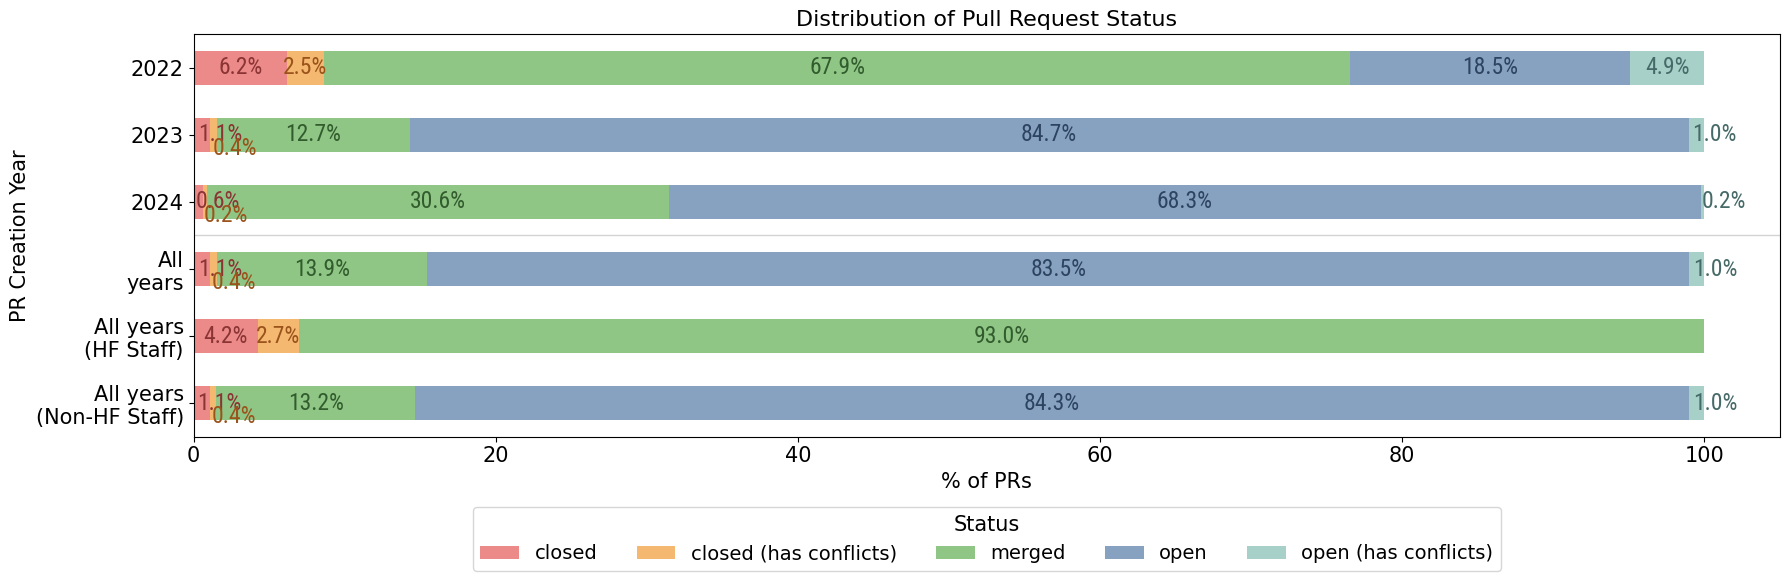

In [5]:
from matplotlib.font_manager import FontProperties
import matplotlib.pyplot as plt
from nb_utils import RESULTS_DIR, ROBOTO_CONDENSED_FONT

# Group by year and status, and calculate counts
status_counts = df.groupby(['year', 'status']).size().unstack(fill_value=0)

# Calculate percentage distribution for each year
status_percentage = status_counts.div(status_counts.sum(axis=1), axis=0) * 100

# Calculate total counts for all years and add as a new row
total_counts = df['status'].value_counts(normalize=True) * 100  # Percentage distribution for the entire dataset
status_percentage.loc['All\nyears'] = total_counts.reindex(status_percentage.columns).fillna(0)  # Add 'Total' row
# calculate the percentage of PRs that were made by HF staff
# hf_staff_counts = df[df['was_status_changed_by_hf_staff' == True]]['status'].value_counts(normalize=True) * 100
hf_staff_counts = df[df['was_status_changed_by_hf_staff'] == True]['status'].value_counts(normalize=True) * 100
status_percentage.loc['All years\n(HF Staff)'] = hf_staff_counts.reindex(status_percentage.columns).fillna(0)  # Add 'Total' row
hf_staff_counts = df[df['was_status_changed_by_hf_staff'] == False]['status'].value_counts(normalize=True) * 100
status_percentage.loc['All years\n(Non-HF Staff)'] = hf_staff_counts.reindex(status_percentage.columns).fillna(0)  # Add 'Total' row

# Reverse the order of the years to display from bottom to top
status_percentage = status_percentage[::-1]

# Define Tableau-like color palette for the status categories
colors = {
    'open': '#87a1c1',  # Lighter Blue
    'merged': '#8fc685',  # Lighter Green
    'closed': '#ec8a89',  # Lighter Red
    'closed (has conflicts)': '#f5b870',  # Lighter Orange
    'open (has conflicts)': '#a7d0c8',  # Lighter Teal
}

# Define even darker versions of the Tableau-like color palette
darker_colors = {
    'open': '#2d4460',  # Even Darker Blue
    'merged': '#325c2d',  # Even Darker Green
    'closed': '#8a3434',  # Even Darker Red
    'closed (has conflicts)': '#9a531b',  # Even Darker Orange
    'open (has conflicts)': '#466a68',  # Even Darker Teal
}



# Plot the 100% stacked bar chart as horizontal with Tableau-like colors
fig, ax = plt.subplots(figsize=(18, 6))
status_percentage.plot(kind='barh', stacked=True, ax=ax, color=[colors[status] for status in status_percentage.columns])

# Add data labels for each segment with matching colors
for i, (year, row) in enumerate(status_percentage.iterrows()):
    cumulative = 0
    delta = 0.2  # Offset for small segments
    was_small = False
    for status, value in row.items():
        if value > 2:  # Only display labels for segments > 5% to prevent overlap
            ax.text(cumulative + value / 2, i, f"{value:.1f}%", ha='center', va='center',
                    fontsize=17, fontweight='bold', fontproperties=ROBOTO_CONDENSED_FONT,
                    color=darker_colors[status])  # Set text color to match bar color
            was_small = False
        elif value > 0:
            # For small segments, place the label outside with matching color
            ax.text(cumulative + value / 4, i + (delta if was_small else 0), f"{value:.1f}%", ha='left', va='center',
                    fontsize=17, fontweight='bold', fontproperties=ROBOTO_CONDENSED_FONT,
                    color=darker_colors[status])
            delta = -delta
            was_small = True
        cumulative += value

# Add a red line separating the "Total" bar from the yearly data
ax.axhline(y=len(status_percentage) - 3.5, color='lightgray', linewidth=1)

# Customize plot with larger font sizes
plt.title('Distribution of Pull Request Status', fontsize=16)
plt.ylabel('PR Creation Year', fontsize=15)
plt.xlabel('% of PRs', fontsize=15)
# increase tick size
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.grid(False)

# Move the legend outside and below the chart with increased label size
plt.legend(title='Status', bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=len(status_percentage.columns),
           fontsize=14, title_fontsize=15)
plt.tight_layout()

# Save the plot to a PDF
plt.savefig(RESULTS_DIR / 'RQ3StatusDistribution.pdf', format='pdf', bbox_inches='tight')


plt.show()

## How many PRs are merged by a hugging face staff?


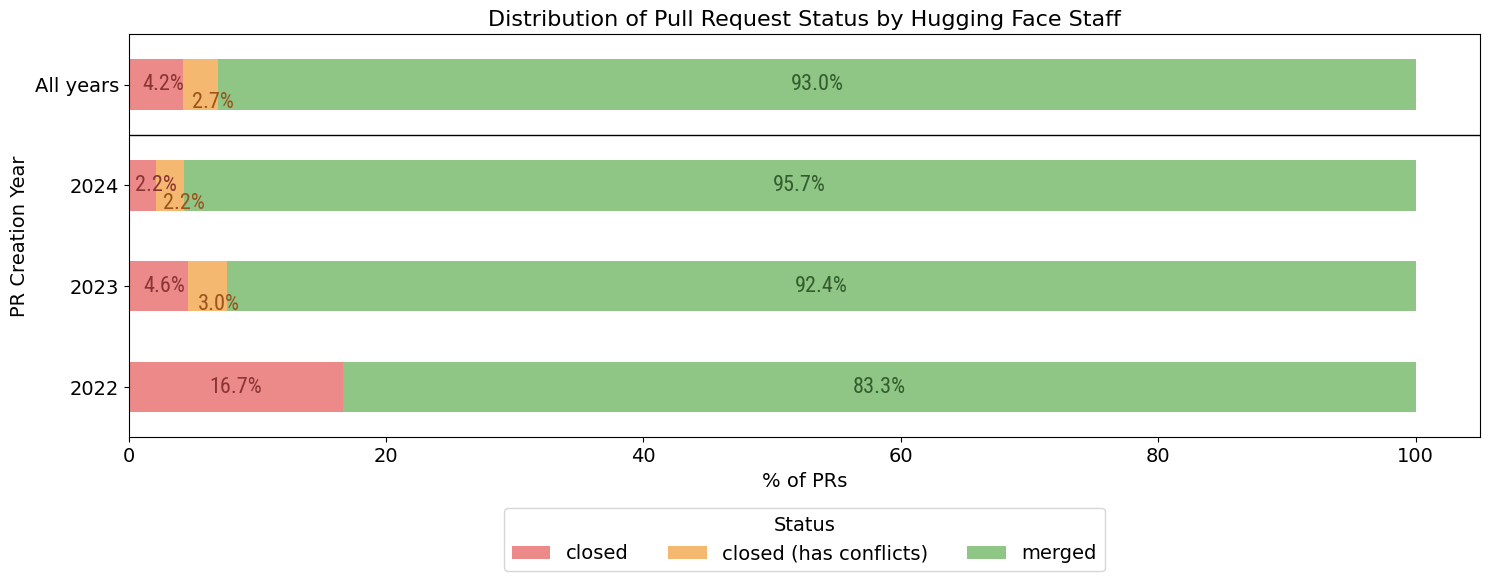

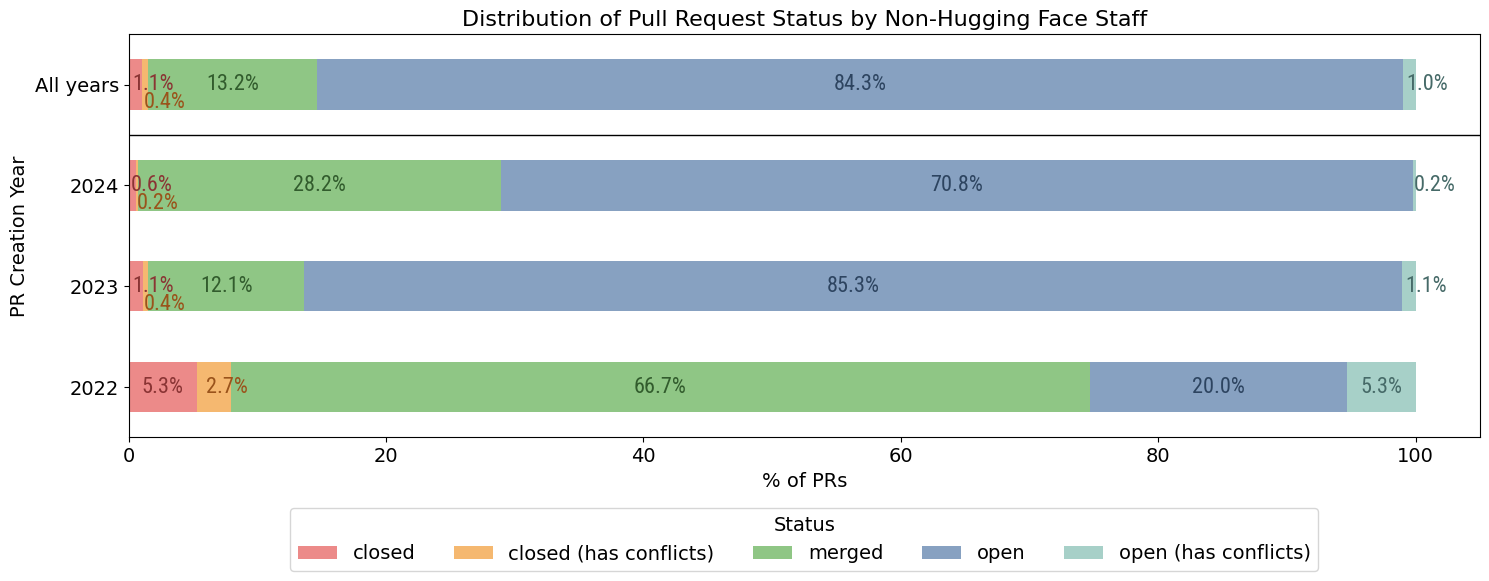

(401, 43195)

In [6]:
from matplotlib.font_manager import FontProperties
import matplotlib.pyplot as plt
from nb_utils import RESULTS_DIR, ROBOTO_CONDENSED_FONT

def plot(df, title_suffix):
    
    
    # Group by year and status, and calculate counts
    status_counts = df.groupby(['year', 'status']).size().unstack(fill_value=0)
    
    # Calculate percentage distribution for each year
    status_percentage = status_counts.div(status_counts.sum(axis=1), axis=0) * 100
    
    # Calculate total counts for all years and add as a new row
    total_counts = df['status'].value_counts(normalize=True) * 100  # Percentage distribution for the entire dataset
    status_percentage.loc['All years'] = total_counts.reindex(status_percentage.columns).fillna(0)  # Add 'Total' row
    
    # Define Tableau-like color palette for the status categories
    colors = {
        'open': '#87a1c1',  # Lighter Blue
        'merged': '#8fc685',  # Lighter Green
        'closed': '#ec8a89',  # Lighter Red
        'closed (has conflicts)': '#f5b870',  # Lighter Orange
        'open (has conflicts)': '#a7d0c8',  # Lighter Teal
    }
    
    # Define even darker versions of the Tableau-like color palette
    darker_colors = {
        'open': '#2d4460',  # Even Darker Blue
        'merged': '#325c2d',  # Even Darker Green
        'closed': '#8a3434',  # Even Darker Red
        'closed (has conflicts)': '#9a531b',  # Even Darker Orange
        'open (has conflicts)': '#466a68',  # Even Darker Teal
    }
    

    
    # Plot the 100% stacked bar chart as horizontal with Tableau-like colors
    fig, ax = plt.subplots(figsize=(15, 6))
    status_percentage.plot(kind='barh', stacked=True, ax=ax, color=[colors[status] for status in status_percentage.columns])
    
    # Add data labels for each segment with matching colors
    for i, (year, row) in enumerate(status_percentage.iterrows()):
        cumulative = 0
        delta = 0.18  # Offset for small segments
        was_small = False
        for status, value in row.items():
            if value > 5:  # Only display labels for segments > 5% to prevent overlap
                ax.text(cumulative + value / 2, i, f"{value:.1f}%", ha='center', va='center',
                        fontsize=16, fontweight='bold', fontproperties=ROBOTO_CONDENSED_FONT,
                        color=darker_colors[status])  # Set text color to match bar color
                was_small = False
            elif value > 0:
                # For small segments, place the label outside with matching color
                ax.text(cumulative + value / 4, i + (delta if was_small else 0), f"{value:.1f}%", ha='left', va='center',
                        fontsize=16, fontweight='bold', fontproperties=ROBOTO_CONDENSED_FONT,
                        color=darker_colors[status])
                delta = -delta
                was_small = True
            cumulative += value
    
    # Add a red line separating the "Total" bar from the yearly data
    ax.axhline(y=len(status_percentage) - 1.5, color='black', linewidth=1)
    
    # Customize plot with larger font sizes
    plt.title(f'Distribution of Pull Request Status by {title_suffix}', fontsize=16)
    plt.ylabel('PR Creation Year', fontsize=14)
    plt.xlabel('% of PRs', fontsize=14)
    # increase tick size
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    
    # Move the legend outside and below the chart with increased label size
    plt.legend(title='Status', bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=len(status_percentage.columns),
               fontsize=14, title_fontsize=14)
    plt.tight_layout()
    
    # Save the plot to a PDF
    plt.savefig(RESULTS_DIR / f'RQ3StatusDistribution-{title_suffix}.pdf', format='pdf', bbox_inches='tight')
    
    plt.show()

# filter df1 to only include PRs that were merged by hugging face staff
df1_hf_staff = df[df['was_status_changed_by_hf_staff'] == True]
plot(df1_hf_staff, 'Hugging Face Staff')

# filter df1 to only include PRs that were merged by non-hugging face staff
df1_non_hf_staff = df[df['was_status_changed_by_hf_staff'] == False]
plot(df1_non_hf_staff, 'Non-Hugging Face Staff')
len(df1_hf_staff), len(df1_non_hf_staff)

## Time to response
We plot a box plot of the time to first response for each status category.

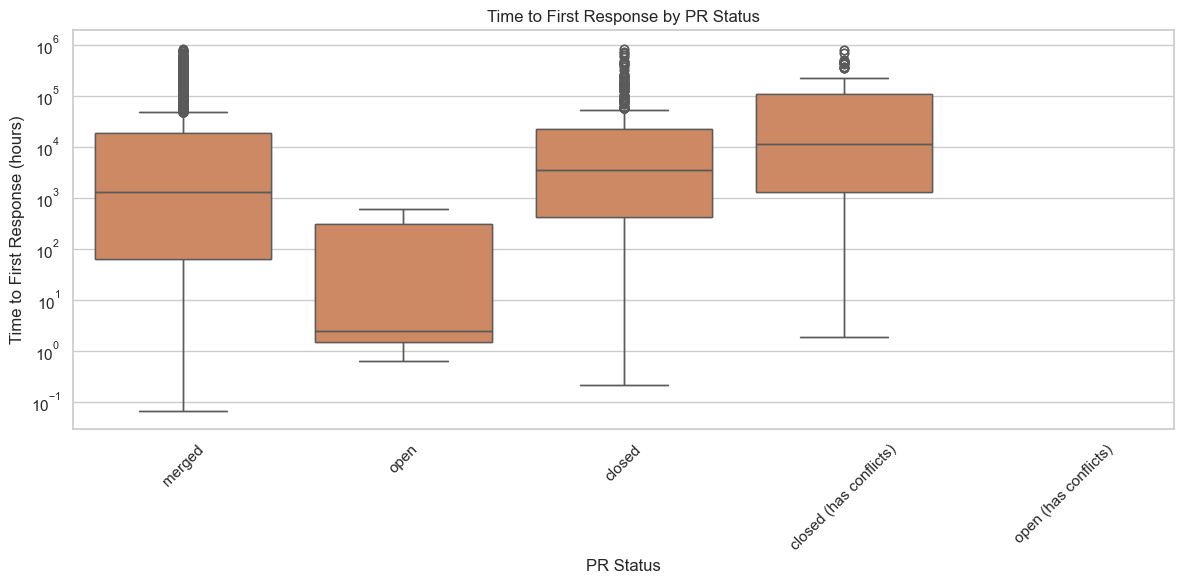

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
from nb_utils import RESULTS_DIR

# Filter out PRs with no response
df_time_to_response = df[df['time_to_first_response'] != 'No response']
# Convert time to response to minutes
df_time_to_response['time_to_first_response'] = pd.to_timedelta(df_time_to_response['time_to_first_response'])
df_time_to_response['time_to_first_response'] = df_time_to_response[
                                                    'time_to_first_response'].dt.total_seconds() / 60  #3600
# Plot the box plot
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
# do a box plot including the outliers in the plot (dont leave it out as circles)
sns.boxplot(data=df_time_to_response, x='status', y='time_to_first_response', showfliers=True)
sns.boxplot(data=df_time_to_response, x='status', y='time_to_first_response', showfliers=True)
# sns.boxplot(data=df_time_to_response, x='status', y='time_to_first_response', palette=colors)
# do a violin plot
# sns.violinplot(data=df_time_to_response, x='status', y='time_to_first_response', palette=colors)
plt.yscale('log')  # Log scale for better visualization
plt.title('Time to First Response by PR Status')
plt.xlabel('PR Status')
plt.ylabel('Time to First Response (hours)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'RQ3TimeToFirstResponse.pdf', format='pdf')
plt.show()



## Identify Relevant Discussions

Criteria:
1. PR has at least two non-empty comment.
2. PR has at least two different authors (not counting the SFConvertBot) engaging in the discussion.
3. The average comment size is more than 4 words.

In [8]:
from nb_utils import RESULTS_DIR
from tqdm import tqdm
import json

min_num_authors = 2
min_num_comments = 2
min_avg_comment_size = 0

output_file = RESULTS_DIR / 'sfconvertbot_pr_metadata_filtered.csv'
# create a dataframe to store the filtered PRs
df_filtered = pd.DataFrame(columns=df.columns)
# create lambda function that checks whether string.lower() == 'sfconvertbot'
is_sfconvertbot = lambda x: x.lower() == 'sfconvertbot'

# iterate over dataframe
for index, row in tqdm(df.iterrows(), total=len(df)):
    # parse as JSON (it should be a string)
    discussion = json.loads(row['discussion_metadata'])['discussion']
    # extract events and original author
    events = discussion['events']
    original_author = discussion['author']
    # criteria:
    num_words, num_non_empty_comments = 0, 0
    authors = set()
    if not is_sfconvertbot(original_author["name"]):
        authors.add(original_author["name"])

    for event in events:
        # print("\t",event)
        event_type = event['type']
        if event_type == 'comment' and not event['data']['hidden']:
            event_author = event['author']
            num_non_empty_comments += 1
            if not is_sfconvertbot(event_author["name"]):
                authors.add(event_author["name"])
            num_words += len(event['data']['latest']['raw'].split())

    should_include = (num_non_empty_comments >= min_num_comments and
                      len(authors) >= min_num_authors and
                      num_words / num_non_empty_comments >= min_avg_comment_size)
    # add the row to the filtered dataframe
    if should_include:
        df_filtered.loc[len(df_filtered)] = row
        title = f"{discussion['title']} by {original_author['name']} ({row['model_id']})"
        df_filtered.loc[len(df_filtered) - 1, 'title'] = title
        df_filtered.loc[len(df_filtered) - 1, 'num_comments'] = num_non_empty_comments
        df_filtered.loc[len(df_filtered) - 1, 'num_authors'] = len(authors)
        df_filtered.loc[len(df_filtered) - 1, 'avg_comment_size'] = num_words / num_non_empty_comments
        df_filtered.loc[len(df_filtered) - 1, 'authors'] = ";".join(authors)

# add a source column
df_filtered['source'] = 'SFConvertBot PRs'
# rename PR URL column to url
df_filtered.rename(columns={'pr_url': 'url'}, inplace=True)
# rename discussion_metadata to json_content
df_filtered.rename(columns={'discussion_metadata': 'json_content'}, inplace=True)
# reorder columns
df_filtered = df_filtered[['source', 'title', 'url', 'num_comments', 'num_authors', 'avg_comment_size', 'authors']]
# save the filtered dataframe
df_filtered.to_csv(output_file, index=True)
print("Number of PRs after filtering: ", len(df_filtered))
print("Saved to: ", output_file)

  0%|          | 0/43596 [00:00<?, ?it/s]/var/folders/8r/8ct8ssl93_v7yvgp8s_cylgm0000gn/T/ipykernel_65093/2474156956.py:43: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_filtered.loc[len(df_filtered)] = row
  2%|▏         | 780/43596 [00:00<00:05, 7799.77it/s]/var/folders/8r/8ct8ssl93_v7yvgp8s_cylgm0000gn/T/ipykernel_65093/2474156956.py:43: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_filtered.loc[len(df_filtered)] = row
 18%|█▊        | 7808/43596 [00:00<00:01, 29225.74it/s]/var/folders/

Number of PRs after filtering:  27
Saved to:  ../../results/sfconvertbot_pr_metadata_filtered.csv


## PR Baseline for the same repos that received a PR from SFConvertBot

In [20]:
df_baseline = pd.read_csv('../../data/repo_pr_baseline.csv')
df_baseline

,model_id,num,is_conversion,status
0,nielsr/nt5-small-rc1,3,True,open
1,nielsr/nt5-small-rc1,2,False,merged
2,nielsr/nt5-small-rc1,1,True,open
3,weqweasdas/hh_rlhf_rm_open_llama_3b,3,True,open
4,weqweasdas/hh_rlhf_rm_open_llama_3b,2,True,open
...,...,...,...,...
65132,pchatz/palobert-base-greek-social-media,2,True,open
65133,pchatz/palobert-base-greek-social-media,1,True,open
65134,babylm/t5-base-strict,1,True,open
65135,zhaozh/autotrain-pubmed-medft-tiny-46854115566,1,True,open


In [21]:
conv  = df_baseline[df_baseline.is_conversion]
other = df_baseline[~df_baseline.is_conversion]

def merge_rate(x):
    return (x.status == 'merged').sum(), len(x), (x.status == 'merged').mean()

cm, ct, cr = merge_rate(conv)
om, ot, orr = merge_rate(other)
print(f"Conversion PRs merged: {cm}/{ct} = {cr:.1%}")
print(f"Other PRs merged:      {om}/{ot} = {orr:.1%}")

Conversion PRs merged: 6424/47349 = 13.6%
Other PRs merged:      5385/17788 = 30.3%


In [24]:
#checking repos that have any other PRs (other than the conversion bot) just to make a fairer analysis

repos_with_other = set(other.model_id.unique())
c2 = conv[conv.model_id.isin(repos_with_other)]
o2 = other[other.model_id.isin(repos_with_other)]

print(f"Repos with >=1 non-conversion PR: {len(repos_with_other)} of {df_baseline.model_id.nunique()}")
print(f"  Conversion PRs merged: {(c2.status=='merged').mean():.1%}")
print(f"  Other PRs merged:      {(o2.status=='merged').mean():.1%}")

Repos with >=1 non-conversion PR: 8734 of 36135
  Conversion PRs merged: 13.7%
  Other PRs merged:      30.3%


In [ ]:
#merge rate for each repo
g = df_baseline.groupby(['model_id', 'is_conversion']).status.apply(
    lambda s: (s == 'merged').mean()).unstack()
g.columns = ['other_rate', 'conv_rate']   # False, True
paired = g.dropna()   # repos with both types

singled_out = ((paired.other_rate > 0) & (paired.conv_rate == 0)).sum()
print(f"Repos with both PR types: {len(paired)}")
print(f"  ...where others merged but conversion did NOT: {singled_out} ({singled_out/len(paired):.1%})")

Repos with both PR types: 8583
  ...where others merged but conversion did NOT: 1508 (17.6%)
